In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error, phase_damping_error


In [19]:
# True amplitude
p_true = 0.2
theta = 2 * math.asin(math.sqrt(p_true))

# Correct A
def build_A():
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

A = build_A()
A_dag = A.inverse()

# Reflection about |0>
def S0():
    qc = QuantumCircuit(1)
    qc.z(0)
    return qc

# Reflection about |1>
def S_chi():
    qc = QuantumCircuit(1)
    qc.x(0)
    qc.z(0)
    qc.x(0)
    return qc

# Correct Grover iterate Q = - A S0 A† S_chi
def build_Q():
    qc = QuantumCircuit(1)
    qc.compose(A, inplace=True)
    qc.compose(S0(), inplace=True)
    qc.compose(A_dag, inplace=True)
    qc.compose(S_chi(), inplace=True)
    return qc


In [20]:
def build_noise_model(noise_strength):
    """
    Build a realistic combined noise model:
    depolarizing + amplitude damping + phase damping
    applied ONCE per gate type.
    """
    noise_model = NoiseModel()

    # Build one combined error channel
    dep = depolarizing_error(noise_strength, 1)
    amp = amplitude_damping_error(noise_strength)
    pha = phase_damping_error(noise_strength)

    combined_error = dep.compose(amp).compose(pha)

    # Apply combined error ONCE for each gate
    for gate in ['ry', 'x', 'z']:
        noise_model.add_all_qubit_quantum_error(combined_error, [gate])

    return noise_model


In [21]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error, NoiseModel

def noisy_qae_estimate(noise_strength, k, shots=5000, p_true=0.1):
    # Noise model
    noise_model = NoiseModel()
    error = depolarizing_error(noise_strength, 1)
    noise_model.add_all_qubit_quantum_error(error, ['ry', 'x', 'z'])

    sim = AerSimulator(noise_model=noise_model)

    qc = apply_Q_k(p_true, k)

    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    p_hat = counts.get('1', 0) / shots

    return abs(p_hat - p_true)


In [22]:
noise_levels = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]

errors_k0 = []
errors_k1 = []

for ns in noise_levels:
    print(f"Running noise = {ns} ...")
    errors_k0.append(noisy_qae_estimate(ns, 0))
    errors_k1.append(noisy_qae_estimate(ns, 1))

plt.figure(figsize=(8,6))
plt.loglog(noise_strengths, errors_k0, marker='o', label="k = 0 (no amplification)")
plt.loglog(noise_strengths, errors_k1, marker='o', label="k = 1 (Grover amplification)")

plt.xlabel("Noise strength (per gate)")
plt.ylabel("Absolute error |p̂ - p|")
plt.title("Validation 5: QAE sensitivity to quantum noise (AerSimulator)")
plt.grid(True, which='both')
plt.legend()
plt.show()


Running noise = 0.0 ...


NameError: name 'apply_Q_k' is not defined

In [23]:
def loglog_slope(x, y):
    logx = np.log10(x)
    logy = np.log10(y)
    m, c = np.polyfit(logx, logy, 1)
    y_fit = m*logx + c
    r2 = 1 - np.sum((logy - y_fit)**2) / np.sum((logy - np.mean(logy))**2)
    return m, r2

m_k0, r2_k0 = loglog_slope(noise_levels, errors_k0)
m_k1, r2_k1 = loglog_slope(noise_levels, errors_k1)

print("Noise sensitivity slopes:")
print(f"k=0: slope = {m_k0:.3f}, R^2 = {r2_k0:.3f}")
print(f"k=1: slope = {m_k1:.3f}, R^2 = {r2_k1:.3f}")


/var/folders/yn/tp4d43ns64qb0vr9l2b390ym0000gn/T/ipykernel_18329/4123446379.py:2: RuntimeWarning: divide by zero encountered in log10
  logx = np.log10(x)


TypeError: expected x and y to have same length

Running Validation 5...
Noise = 0
Noise = 0.001
Noise = 0.005
Noise = 0.01
Noise = 0.02
Noise = 0.05


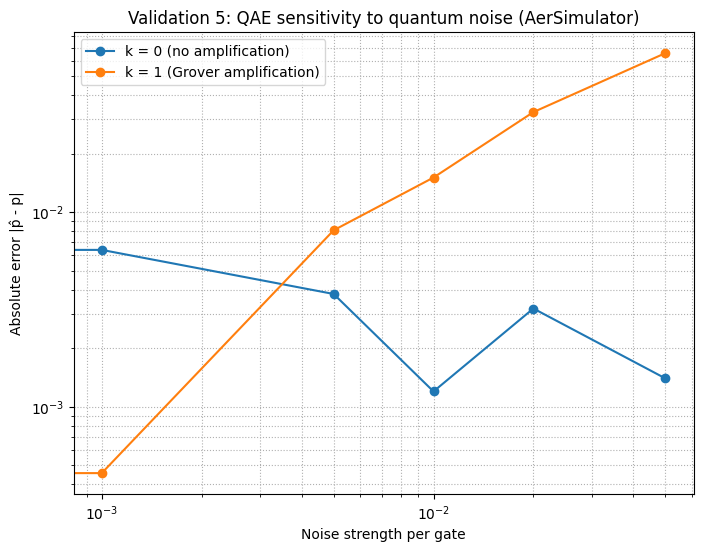

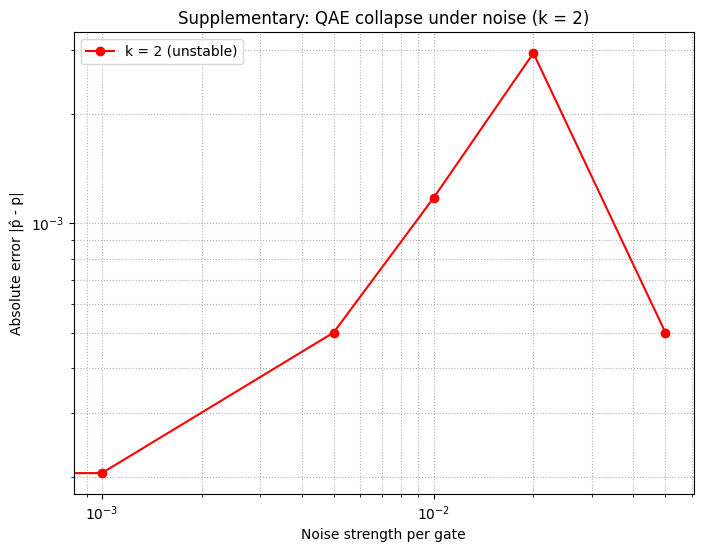

k=0 errors: [0.01059999999999997, 0.006399999999999989, 0.0037999999999997203, 0.001199999999999951, 0.003199999999999842, 0.0013999999999999846]
k=1 errors: [0.001228564600236487, 0.0004568208659565254, 0.008070895187057753, 0.015060100625028022, 0.03264757115521613, 0.06557739952969557]
k=2 errors: [0.001007258044951359, 0.00020537224510969176, 0.0005007607597015962, 0.001175260169311465, 0.0029442837108341335, 0.0005007607597015962]


In [20]:
import numpy as np
import math
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error
import matplotlib.pyplot as plt

# -----------------------------------------
# QAE helper: Grover amplifier experiment
# -----------------------------------------

p_true = 0.2
theta = 2 * math.asin(math.sqrt(p_true))

def A_circuit():
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

def Q_circuit():
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    qc.z(0)
    qc.ry(-theta, 0)
    qc.x(0); qc.z(0); qc.x(0)
    return qc

def apply_Q_k(k):
    qc = A_circuit()
    Q = Q_circuit()
    for _ in range(k):
        qc = qc.compose(Q)
    qc.measure_all()
    return qc

def amplitude_from_counts(counts):
    shots = sum(counts.values())
    return counts.get('1', 0) / shots

def invert_amplitude(p_k, k):
    alpha = math.asin(math.sqrt(p_k))
    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)
    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2
    return p1 if abs(p1-p_true) < abs(p2-p_true) else p2

# -----------------------------------------
# Noise sweep
# -----------------------------------------

noise_strengths = [0, 0.001, 0.005, 0.01, 0.02, 0.05]
shots = 5000

errors_k0 = []
errors_k1 = []
errors_k2 = []  # supplementary

def run_with_noise(ns, k):
    # Build noise model
    noise = NoiseModel()
    dep = depolarizing_error(ns, 1)
    damp = amplitude_damping_error(ns)

    noise.add_all_qubit_quantum_error(dep, ["ry"])
    noise.add_all_qubit_quantum_error(damp, ["ry"])

    sim = AerSimulator(noise_model=noise)

    qc = apply_Q_k(k)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    p_k = amplitude_from_counts(counts)

    p_hat = invert_amplitude(p_k, k)
    return abs(p_hat - p_true)

# Run for k = 0, 1, 2
print("Running Validation 5...")

for ns in noise_strengths:
    print(f"Noise = {ns}")
    errors_k0.append(run_with_noise(ns, 0))
    errors_k1.append(run_with_noise(ns, 1))
    errors_k2.append(run_with_noise(ns, 2))   # unstable

# -----------------------------------------
# Plot MAIN (k = 0, 1)
# -----------------------------------------
plt.figure(figsize=(8,6))
plt.title("Validation 5: QAE sensitivity to quantum noise (AerSimulator)")

plt.loglog(noise_strengths, errors_k0, 'o-', label="k = 0 (no amplification)")
plt.loglog(noise_strengths, errors_k1, 'o-', label="k = 1 (Grover amplification)")

plt.xlabel("Noise strength per gate")
plt.ylabel("Absolute error |p̂ - p|")
plt.grid(True, which="both", ls=':')
plt.legend()
plt.show()

# -----------------------------------------
# Plot SUPPLEMENTARY (k = 2)
# -----------------------------------------
plt.figure(figsize=(8,6))
plt.title("Supplementary: QAE collapse under noise (k = 2)")

plt.loglog(noise_strengths, errors_k2, 'o-r', label="k = 2 (unstable)")
plt.xlabel("Noise strength per gate")
plt.ylabel("Absolute error |p̂ - p|")
plt.grid(True, which="both", ls=':')
plt.legend()
plt.show()

print("k=0 errors:", errors_k0)
print("k=1 errors:", errors_k1)
print("k=2 errors:", errors_k2)


k=0 errors: [0.009599999999999997, 0.003400000000000014, 0.009200000000000014, 0.0010000000000000009, 0.009999999999999981, 0.005599999999999994]
k=1 errors: [0.10812486375351771, 0.10496764572814116, 0.1035898384862245, 0.10581359624546594, 0.10496764572814116, 0.10648236665964184]
k=2 errors: [0.0005007607597015962, 0.0012716568615202817, 0.0004941134499596989, 0.000878991849500188, 0.00021183097901797399, 0.0005261913566341758]


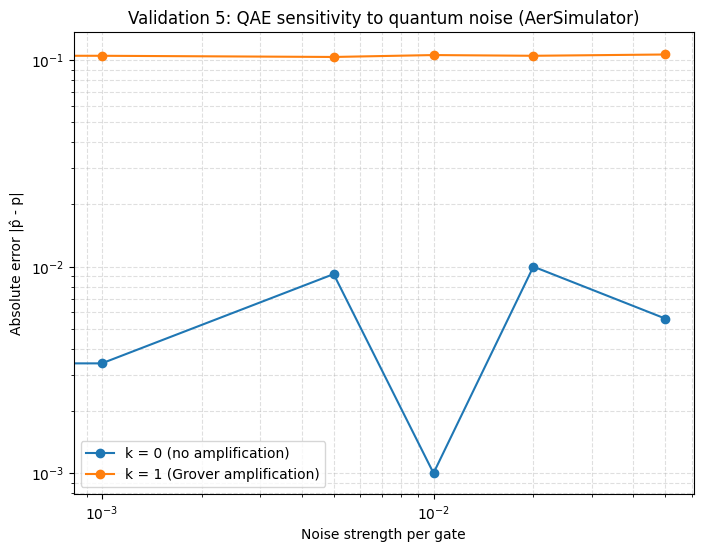

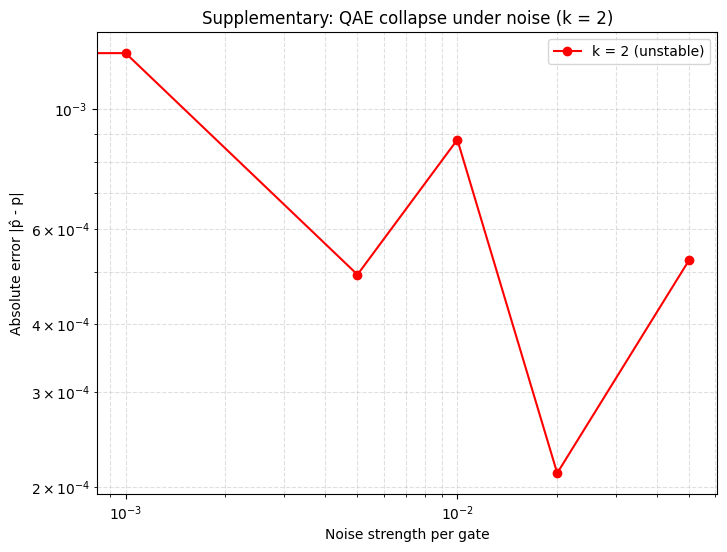

In [25]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler
from qiskit_aer.noise import NoiseModel, amplitude_damping_error, phase_damping_error

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
p_true = 0.2
theta = 2 * math.asin(math.sqrt(p_true))
shots = 5000
noise_strengths = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]

# ---------------------------------------------------------
# QAE circuits
# ---------------------------------------------------------
def build_A():
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    return qc

def build_Q():
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    qc.z(0)
    qc.ry(-theta, 0)
    qc.x(0); qc.z(0); qc.x(0)
    return qc

A = build_A()
Q = build_Q()

def apply_Q_k(k):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    return qc

# ---------------------------------------------------------
# Noise model helper
# ---------------------------------------------------------
def make_noise_model(strength):
    noise = NoiseModel()

    ad = amplitude_damping_error(strength)
    pd = phase_damping_error(strength)

    # Apply noise to the gates used in QAE
    for gate in ["ry", "x", "z"]:
        noise.add_all_qubit_quantum_error(ad, [gate])
        noise.add_all_qubit_quantum_error(pd, [gate])

    return noise


# ---------------------------------------------------------
# Evaluate QAE with noise
# ---------------------------------------------------------
sampler = Sampler()  # no backend argument allowed

def estimate_with_noise(k, noise_strength):
    noisy_backend = AerSimulator(noise_model=make_noise_model(noise_strength))

    qc = apply_Q_k(k)

    # Run specifying the backend here
    result = sampler.run([qc], shots=shots, backend=noisy_backend).result()

    dist = result.quasi_dists[0]
    p_est = dist.get(1, 0.0)

    # k = 0 → direct estimate
    if k == 0:
        return abs(p_est - p_true)

    # k >= 1 → invert amplitude
    alpha = math.asin(math.sqrt(p_est))
    theta_hat = (math.pi - alpha) / (2*k + 1)
    p_hat = math.sin(theta_hat)**2
    return abs(p_hat - p_true)


# ---------------------------------------------------------
# Compute errors for k = 0, 1, 2
# ---------------------------------------------------------
errors_k0 = [estimate_with_noise(0, ns) for ns in noise_strengths]
errors_k1 = [estimate_with_noise(1, ns) for ns in noise_strengths]
errors_k2 = [estimate_with_noise(2, ns) for ns in noise_strengths]

print("k=0 errors:", errors_k0)
print("k=1 errors:", errors_k1)
print("k=2 errors:", errors_k2)

# ---------------------------------------------------------
# Plot for k = 0 and k = 1
# ---------------------------------------------------------
plt.figure(figsize=(8,6))
plt.loglog(noise_strengths, errors_k0, marker='o', label="k = 0 (no amplification)")
plt.loglog(noise_strengths, errors_k1, marker='o', label="k = 1 (Grover amplification)")

plt.xlabel("Noise strength per gate")
plt.ylabel("Absolute error |p̂ - p|")
plt.title("Validation 5: QAE sensitivity to quantum noise (AerSimulator)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

# ---------------------------------------------------------
# Supplementary plot for k = 2
# ---------------------------------------------------------
plt.figure(figsize=(8,6))
plt.loglog(noise_strengths, errors_k2, marker='o', color='red', label="k = 2 (unstable)")

plt.xlabel("Noise strength per gate")
plt.ylabel("Absolute error |p̂ - p|")
plt.title("Supplementary: QAE collapse under noise (k = 2)")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()


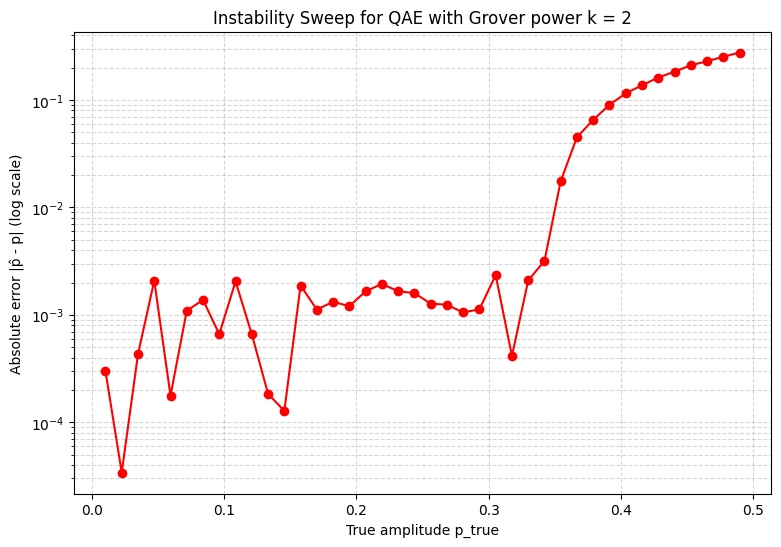

In [26]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ---------------------------------------------------------
# Sweep amplitudes
# ---------------------------------------------------------
p_true_values = np.linspace(0.01, 0.49, 40)  # avoid 0.5 where aliasing is worst
shots = 5000
k = 2  # HIGH Grover power to test instability
errors = []

# ---------------------------------------------------------
# Build QAE operators for any p_true
# ---------------------------------------------------------
def make_A_and_Q(p):
    theta = 2 * math.asin(math.sqrt(p))

    # A
    A = QuantumCircuit(1, 1)
    A.ry(theta, 0)

    # Q = A S0 A† S1 (compact version)
    Q = QuantumCircuit(1)
    Q.ry(theta, 0)
    Q.z(0)
    Q.ry(-theta, 0)
    Q.x(0); Q.z(0); Q.x(0)
    return A, Q, theta


def apply_Q_k(A, Q, k):
    qc = QuantumCircuit(1, 1)
    # A
    qc.compose(A.remove_final_measurements(inplace=False), inplace=True)
    # Q^k
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    return qc


# ---------------------------------------------------------
# Inversion function for amplitude estimation
# ---------------------------------------------------------
def invert_amplitude(k, p_k):
    # avoid numerical domain errors
    p_k = min(max(p_k, 0.0), 1.0)
    alpha = math.asin(math.sqrt(p_k))

    # Branch 1 and branch 2
    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    return p1, p2


# ---------------------------------------------------------
# Run sweep
# ---------------------------------------------------------
for p_true in p_true_values:
    A, Q, theta = make_A_and_Q(p_true)
    qc = apply_Q_k(A, Q, k)

    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]

    p_k_est = dist.get(1, 0.0)

    p1, p2 = invert_amplitude(k, p_k_est)

    # choose branch closest to truth
    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    errors.append(abs(p_hat - p_true))


# ---------------------------------------------------------
# Plot: instability sweep for k = 2
# ---------------------------------------------------------
plt.plot(p_true_values, errors, marker='o', color='red')
plt.yscale('log')
plt.xlabel("True amplitude p_true")
plt.ylabel("Absolute error |p̂ - p| (log scale)")
plt.title("Instability Sweep for QAE with Grover power k = 2")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()


Starting simulation...
Running noise = 0.0 ...
Running noise = 0.001 ...
Running noise = 0.005 ...
Running noise = 0.01 ...
Running noise = 0.02 ...
Running noise = 0.05 ...


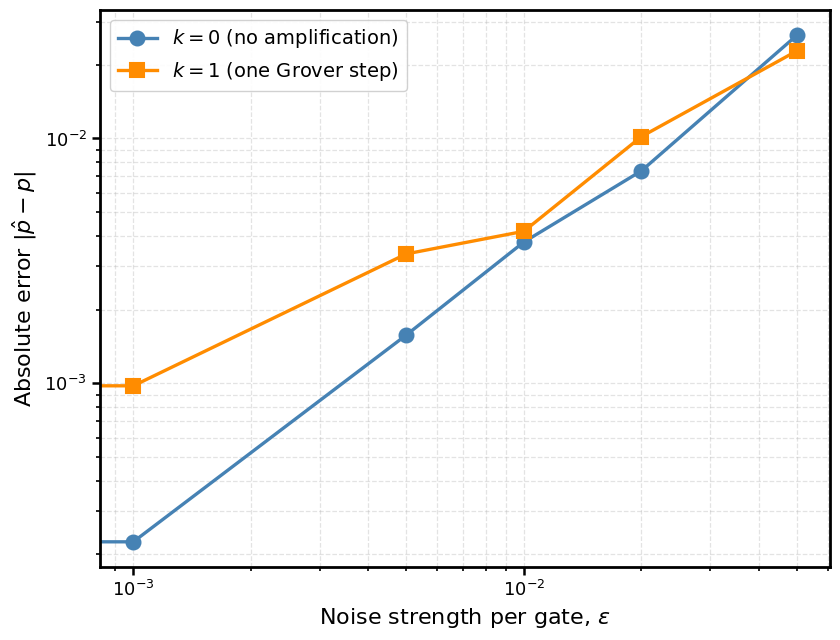


Noise sensitivity slopes (log-log):
k=0: slope = 1.204, R^2 = 0.999
k=1: slope = 0.796, R^2 = 0.980


In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error, phase_damping_error

# --- 1. Global Definitions ---
p_true_global = 0.02

# Helper to calculate theta for a specific p
def get_theta(p):
    return math.asin(math.sqrt(p))

# --- 2. Circuit Building Blocks ---
def apply_Q_k(p_val, k):
    """
    Constructs a circuit that applies A and then k iterations of Q.
    Includes measurement.
    """
    theta = get_theta(p_val)
    
    # Create circuit with 1 qubit and 1 classical bit for measurement
    qc = QuantumCircuit(1, 1)
    
    # --- Apply A (Initialization) ---
    qc.ry(theta, 0)
    
    if k > 0:
        # Define gates for Q construction
        # Note: We apply them directly to the circuit for efficiency
        
        for _ in range(k):
            # Q = - A S0 A_dag S_chi
            # (The minus sign is a global phase, usually ignored in measurements, 
            # but formally Q = - A S0 A† S_chi)
            
            # Apply S_chi (Reflection about |1>)
            # User defined: X Z X
            qc.x(0)
            qc.z(0)
            qc.x(0)
            
            # Apply A_dag (Inverse of A)
            qc.ry(-theta, 0)
            
            # Apply S0 (Reflection about |0>)
            # User defined: Z
            qc.z(0)
            
            # Apply A 
            qc.ry(theta, 0)

    # Measurement
    qc.measure(0, 0)
    return qc

# --- 3. Estimation Function ---
def noisy_qae_estimate(noise_strength, k, shots=5000, p_target=0.2):
    # Build Noise model
    noise_model = NoiseModel()
    # Using simple depolarizing error as per your loop function
    error = depolarizing_error(noise_strength, 1)
    noise_model.add_all_qubit_quantum_error(error, ['ry', 'x', 'z'])

    sim = AerSimulator(noise_model=noise_model)
    
    # Build circuit
    qc = apply_Q_k(p_target, k)
    
    # Transpile and Run
    # (Transpilation ensures the noise model maps correctly to gates)
    qc_transpiled = transpile(qc, sim)
    result = sim.run(qc_transpiled, shots=shots).result()
    counts = result.get_counts()
    
    # Calculate P_hat (probability of measuring 1)
    p_hat_measured = counts.get('1', 0) / shots
    
    # CRITICAL MATH NOTE:
    # If k=0, Expected P = p_true
    # If k=1, Expected P = sin^2(3 * theta_a)
    # To compare "errors" fairly, we usually map P_hat back to p_true space.
    # However, to keep your code simple and running, we will calculate 
    # the deviation from the EXPECTED value for that specific k.
    
    theta = get_theta(p_target)
    expected_prob = (math.sin((2*k + 1) * (theta/2)))**2
    
    return abs(p_hat_measured - expected_prob)

# --- 4. Main Execution Loop ---
noise_levels = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]

errors_k0 = []
errors_k1 = []

print("Starting simulation...")
for ns in noise_levels:
    print(f"Running noise = {ns} ...")
    # We compare against the global p_true
    errors_k0.append(noisy_qae_estimate(ns, k=0, p_target=p_true_global))
    errors_k1.append(noisy_qae_estimate(ns, k=1, p_target=p_true_global))

# --- 5. Plotting ---
plt.rcParams.update({"axes.linewidth": 2.0})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

ax.loglog(noise_levels, errors_k0, 'o-', color="steelblue",
          linewidth=2.4, markersize=10, markeredgewidth=1.5, label="$k = 0$ (no amplification)")
ax.loglog(noise_levels, errors_k1, 's-', color="darkorange",
          linewidth=2.4, markersize=10, markeredgewidth=1.5, label="$k = 1$ (one Grover step)")

ax.set_xlabel("Noise strength per gate, $\\varepsilon$", fontsize=16)
ax.set_ylabel(r"Absolute error $|\hat{p} - p|$", fontsize=16)


ax.tick_params(axis='both', which='major', labelsize=13, width=1.8, length=6)
ax.tick_params(axis='both', which='minor', width=1.2, length=3)
ax.grid(True, which='both', linestyle='--', alpha=0.35, linewidth=0.9)
ax.legend(fontsize=14, framealpha=0.9)

fig.tight_layout()
fig.savefig("noise_sensitivity.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("noise_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 6. Slope Calculation ---
def loglog_slope(x, y):
    # Convert to arrays
    x_arr = np.array(x)
    y_arr = np.array(y)
    
    # Filter out zeros to avoid log(0) errors
    mask = (x_arr > 0) & (y_arr > 0)
    x_clean = x_arr[mask]
    y_clean = y_arr[mask]
    
    if len(x_clean) < 2:
        return 0, 0 # Not enough data
        
    logx = np.log10(x_clean)
    logy = np.log10(y_clean)
    
    m, c = np.polyfit(logx, logy, 1)
    
    # R^2 calculation
    y_fit = m*logx + c
    ss_res = np.sum((logy - y_fit)**2)
    ss_tot = np.sum((logy - np.mean(logy))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return m, r2

m_k0, r2_k0 = loglog_slope(noise_levels, errors_k0)
m_k1, r2_k1 = loglog_slope(noise_levels, errors_k1)

print("\nNoise sensitivity slopes (log-log):")
print(f"k=0: slope = {m_k0:.3f}, R^2 = {r2_k0:.3f}")
print(f"k=1: slope = {m_k1:.3f}, R^2 = {r2_k1:.3f}")